In [13]:
from google.colab import files
uploaded = files.upload()
excel_path = list(uploaded.keys())[0]
print("Loaded:", excel_path)

Saving 3config_seeds0_4_22062026.xlsx to 3config_seeds0_4_22062026.xlsx
Loaded: 3config_seeds0_4_22062026.xlsx


Methods found: ['MILE', 'MFVI', 'Laplace']
Categories (3, object): ['MILE' < 'MFVI' < 'Laplace']
Sizes found: ['small', 'medium', 'large']
Categories (3, object): ['small' < 'medium' < 'large']


/tmp/ipykernel_637/3642143204.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/tmp/ipykernel_637/3642143204.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/tmp/ipykernel_637/3642143204.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showmeans=True)
/tmp/ipykernel_637/3642143204.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data,

Fertig: report.html wurde im aktuellen Arbeitsordner gespeichert.


size,method,ACC,ECE,Brier,LPPD,Entropy,MI
small,MILE,0.5980 ± 0.0321,0.1348 ± 0.0253,0.5579 ± 0.0211,-1.0419 ± 0.0437,1.1825 ± 0.0139,0.0545 ± 0.0077
small,MFVI,0.6318 ± 0.0531,0.0988 ± 0.0183,0.4961 ± 0.0477,-0.9665 ± 0.0812,0.7844 ± 0.0635,0.4138 ± 0.0387
small,Laplace,0.6338 ± 0.0396,0.1597 ± 0.0152,0.5279 ± 0.0480,-1.1476 ± 0.0822,0.5345 ± 0.0778,0.2062 ± 0.0351
medium,MILE,0.5157 ± 0.0425,0.1460 ± 0.0371,0.6460 ± 0.0230,-1.1908 ± 0.0456,1.3163 ± 0.0136,0.0423 ± 0.0049
medium,MFVI,0.6888 ± 0.0426,0.0699 ± 0.0211,0.4379 ± 0.0520,-0.8779 ± 0.1398,0.6621 ± 0.0402,0.4050 ± 0.0319
medium,Laplace,0.6813 ± 0.0387,0.1730 ± 0.0488,0.4855 ± 0.0668,-1.1881 ± 0.2874,0.3730 ± 0.0400,0.1898 ± 0.0338
large,MILE,0.7070 ± 0.0143,0.1420 ± 0.0238,0.4339 ± 0.0124,-0.8170 ± 0.0241,1.0252 ± 0.0180,0.1251 ± 0.0048
large,MFVI,0.7283 ± 0.0154,0.0619 ± 0.0054,0.3963 ± 0.0230,-0.8016 ± 0.0454,0.5496 ± 0.0147,0.3630 ± 0.0132
large,Laplace,0.7233 ± 0.0222,0.1680 ± 0.0137,0.4402 ± 0.0322,-1.1493 ± 0.0989,0.2781 ± 0.0276,0.1598 ± 0.0197
size,method,ACC,ECE,Brier,LPPD,Entropy,MI

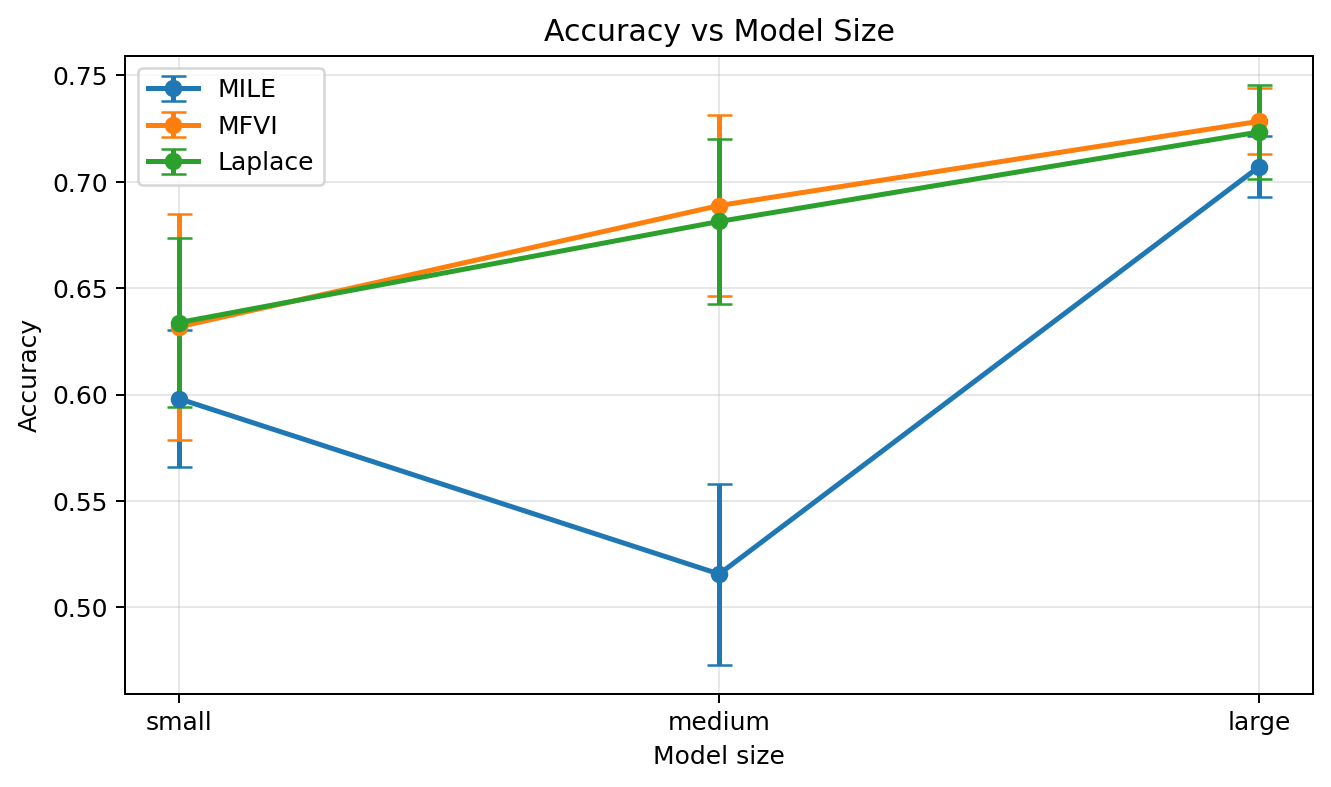
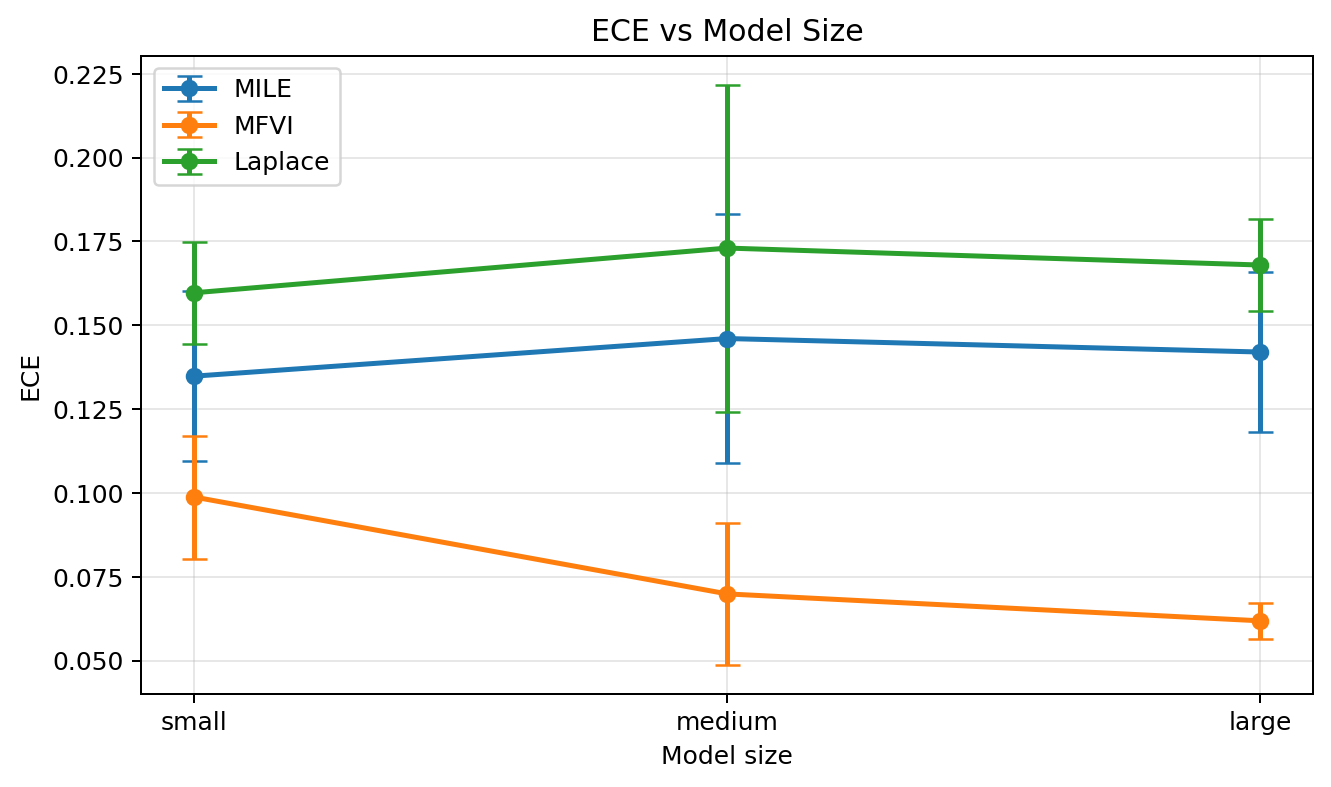
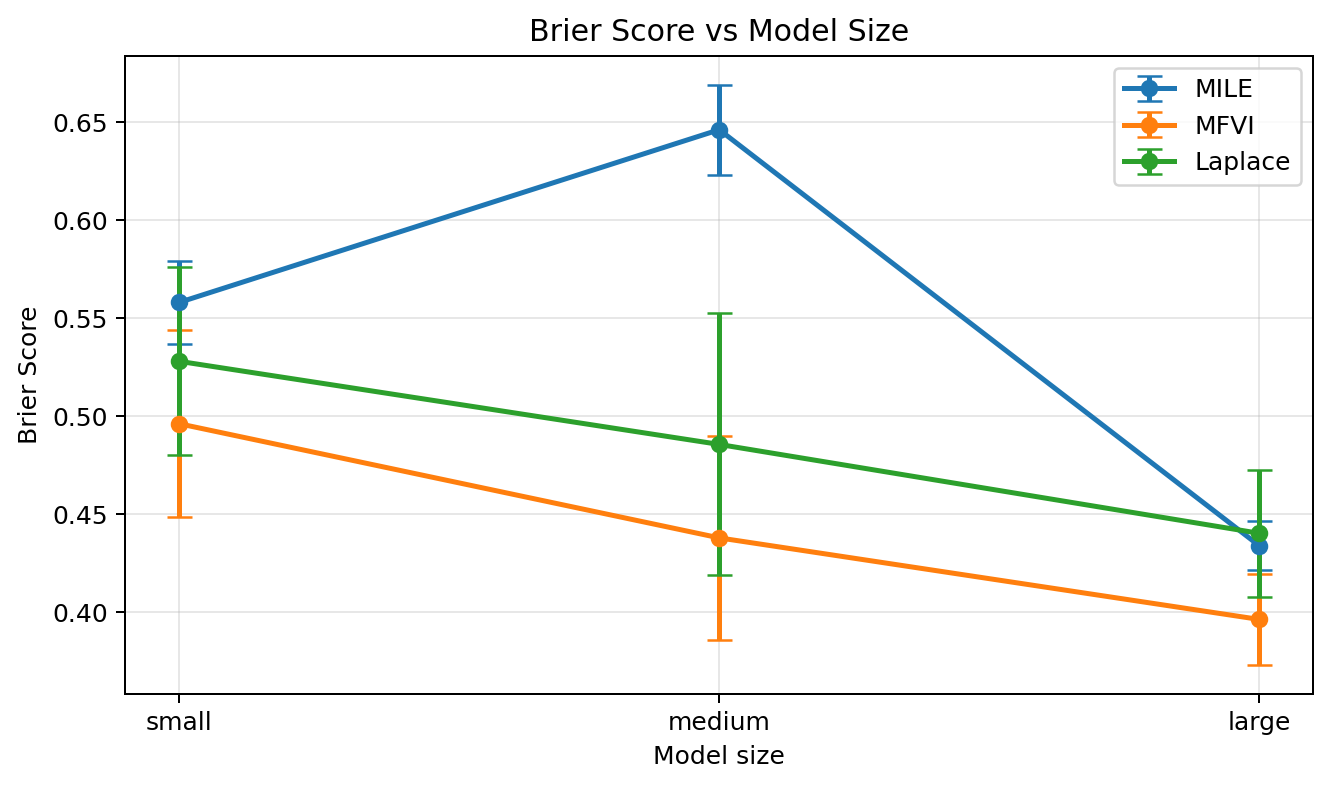
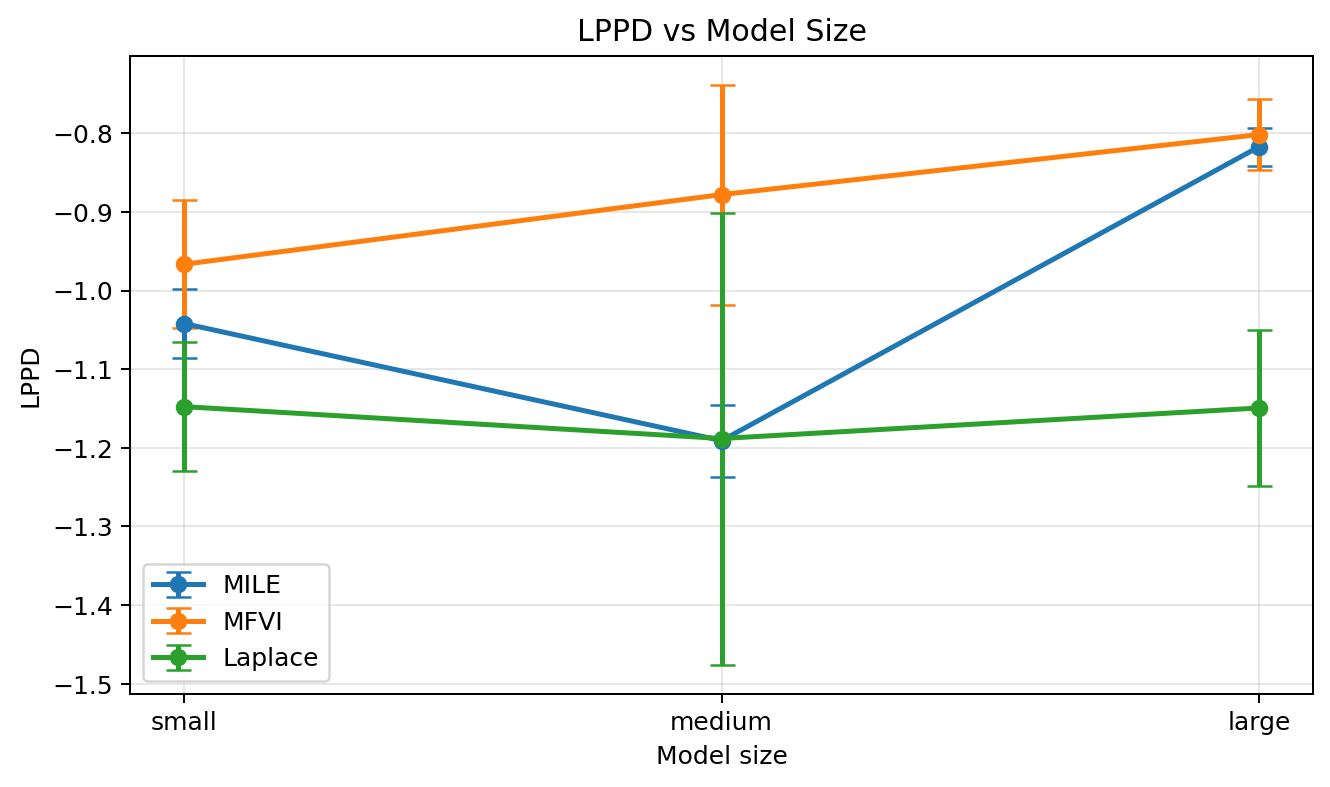
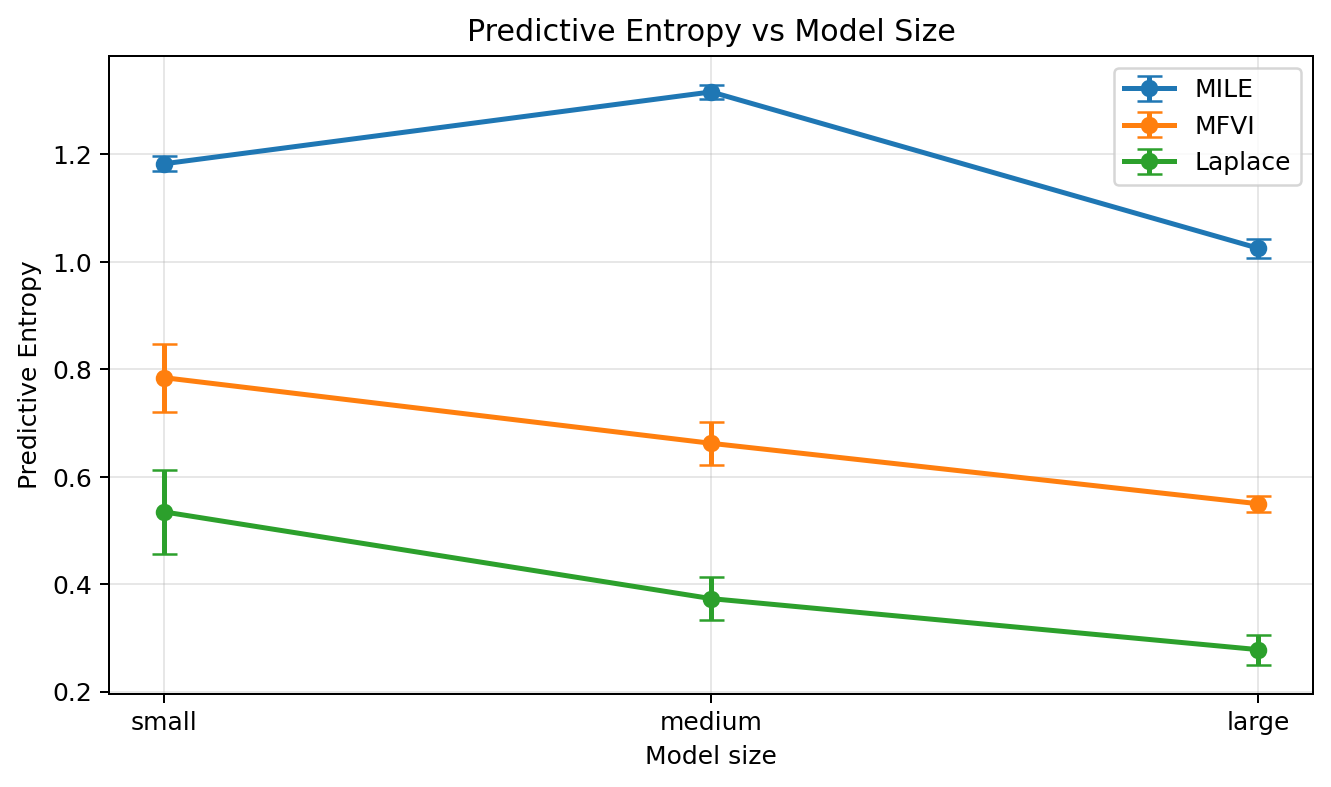
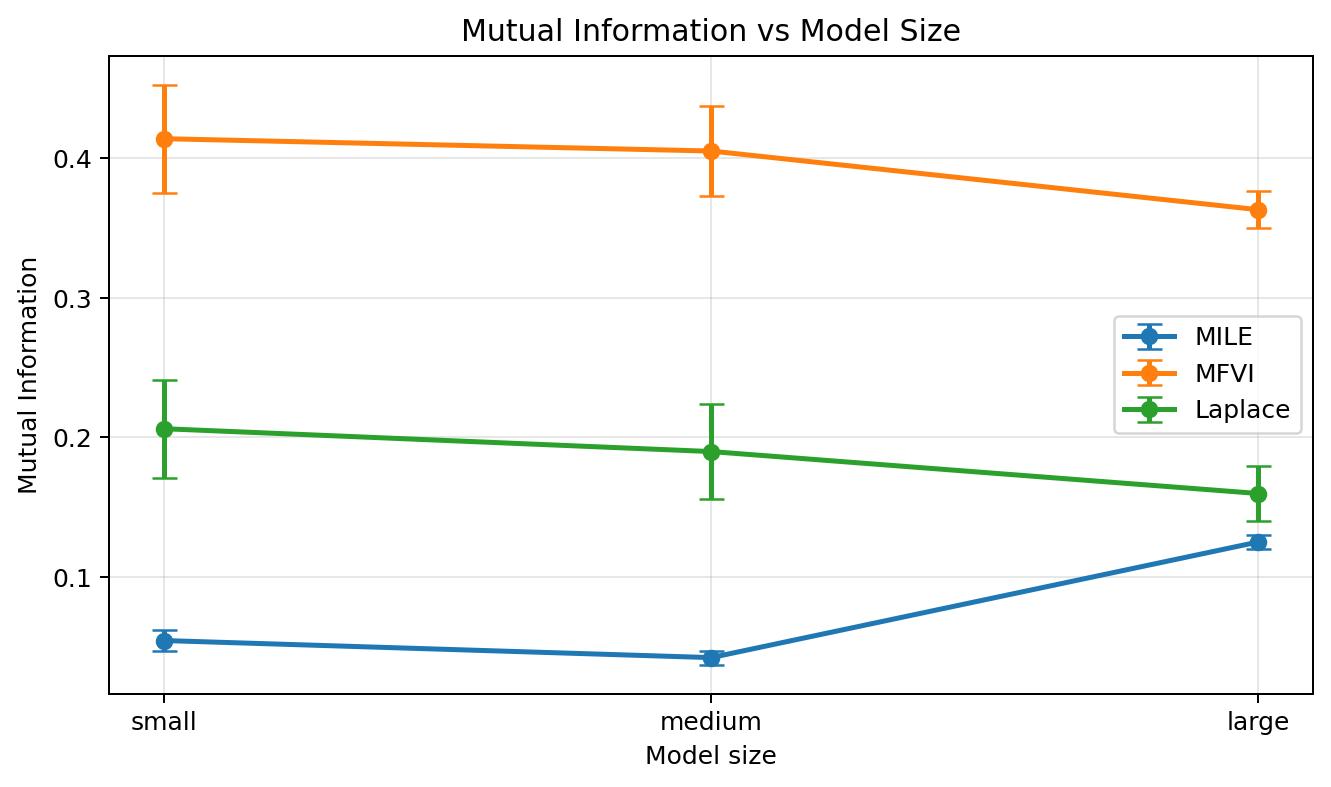
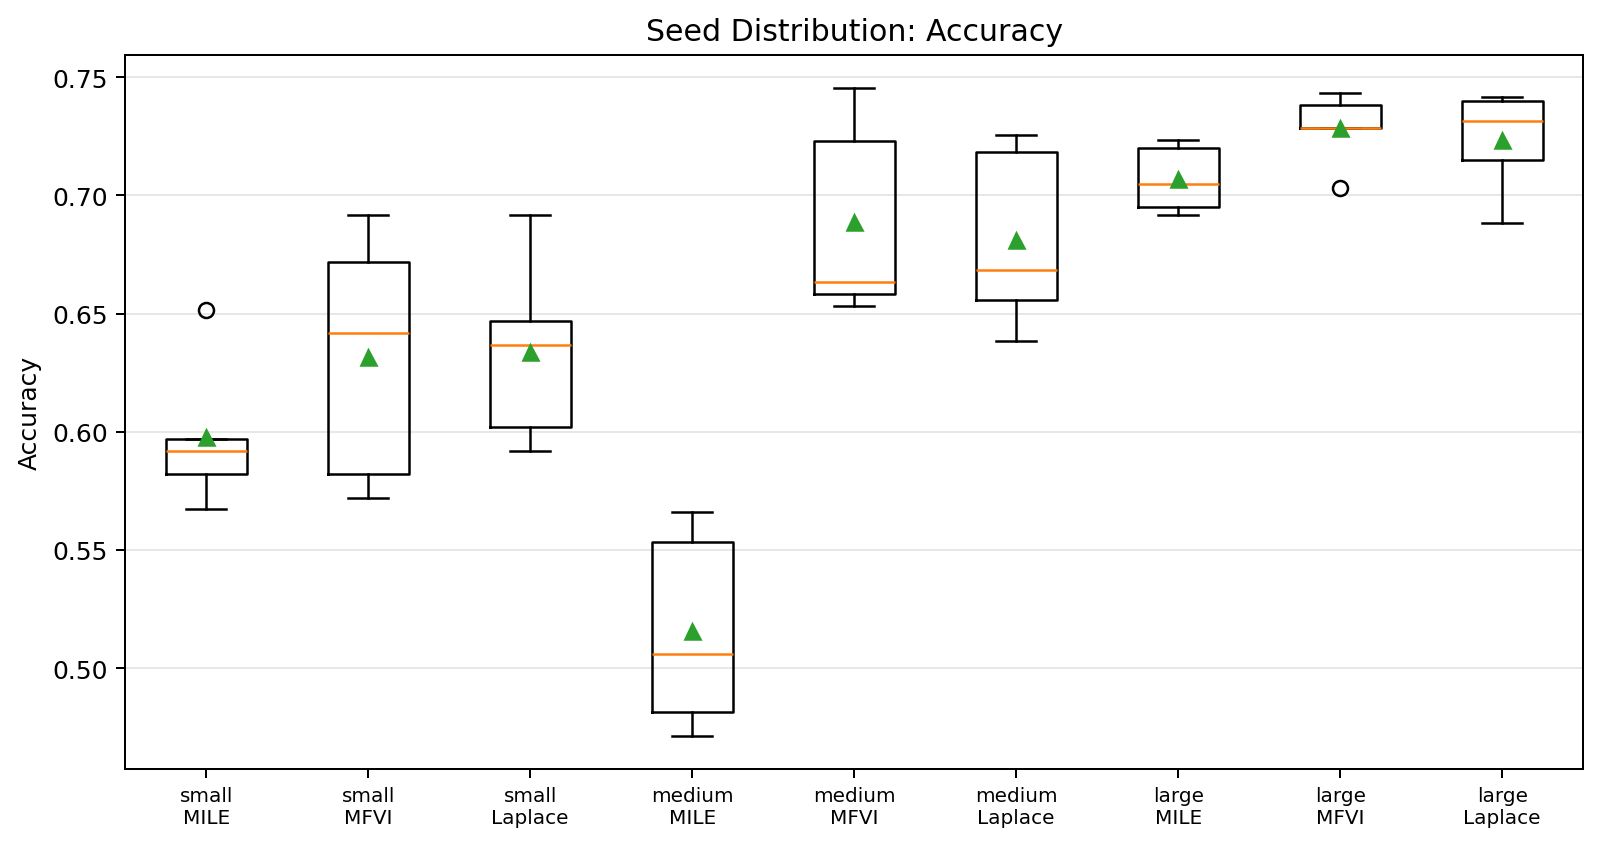
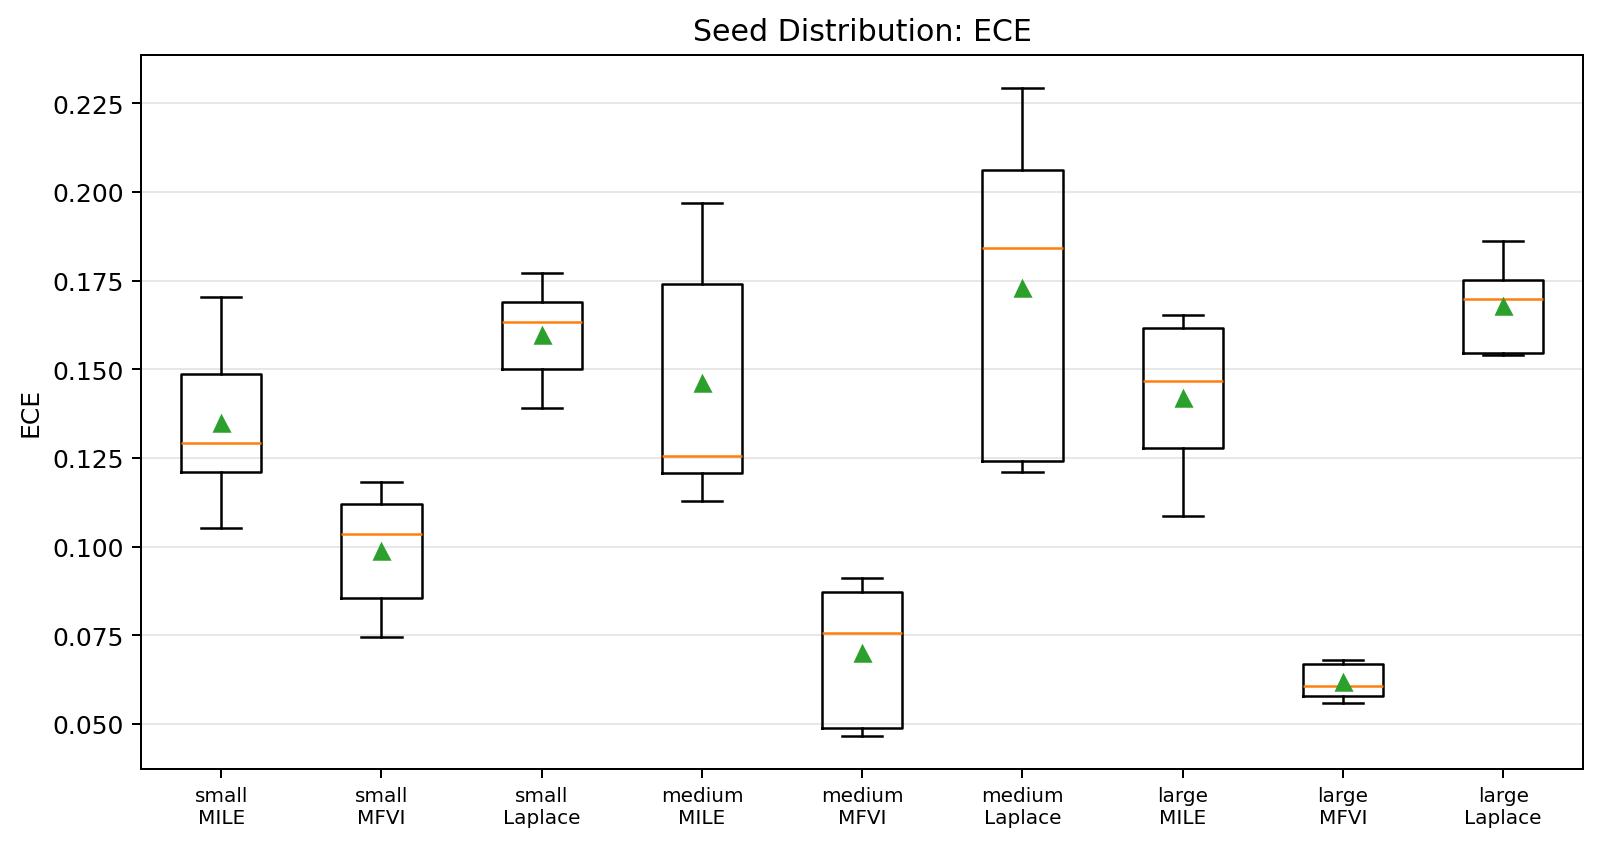
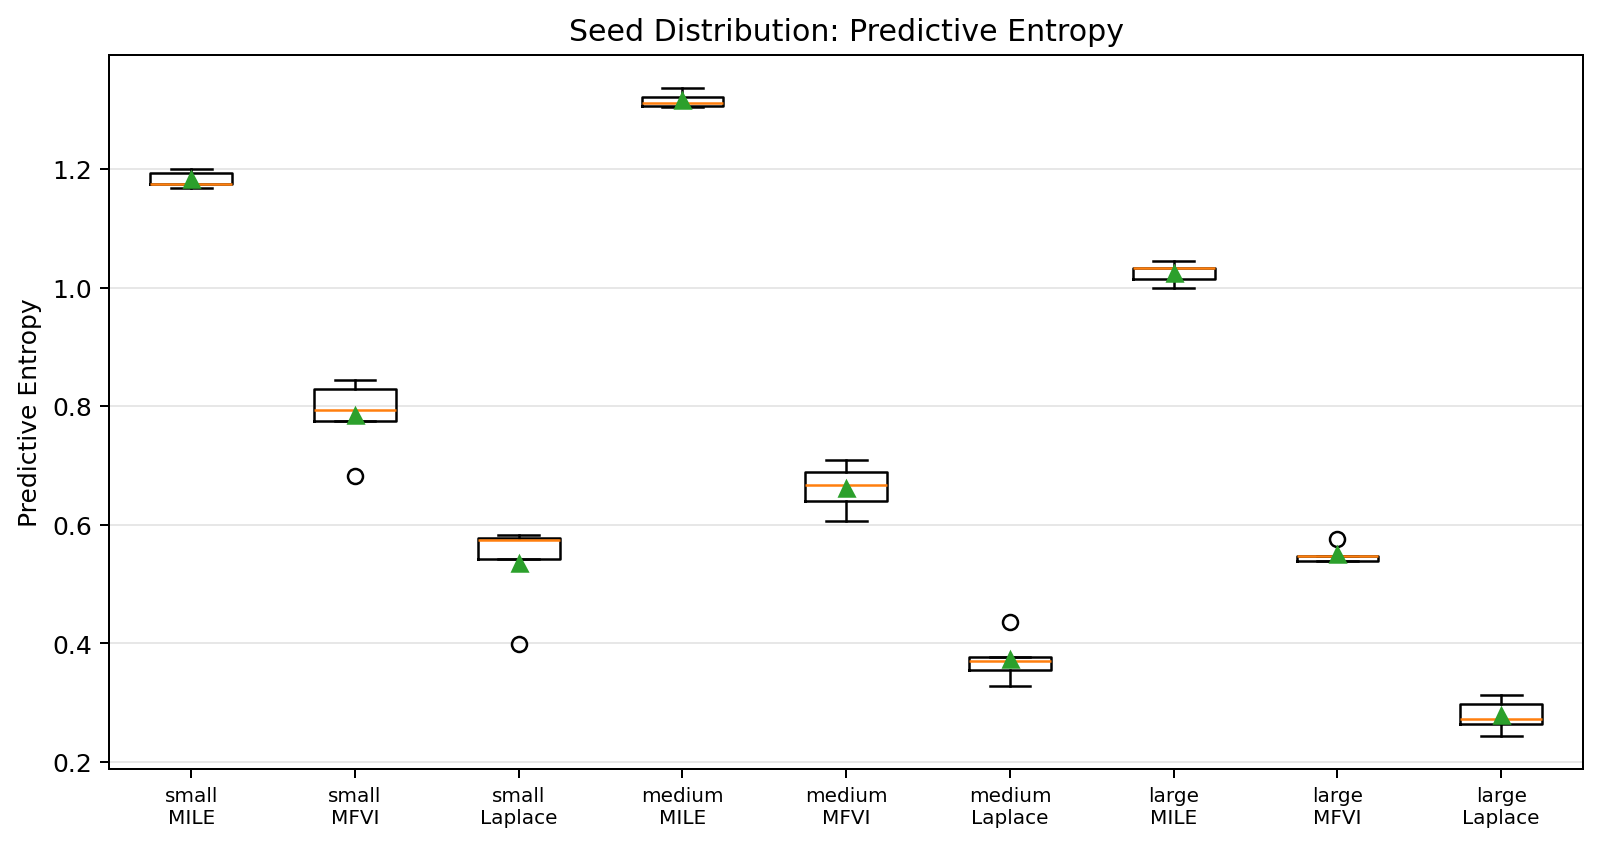
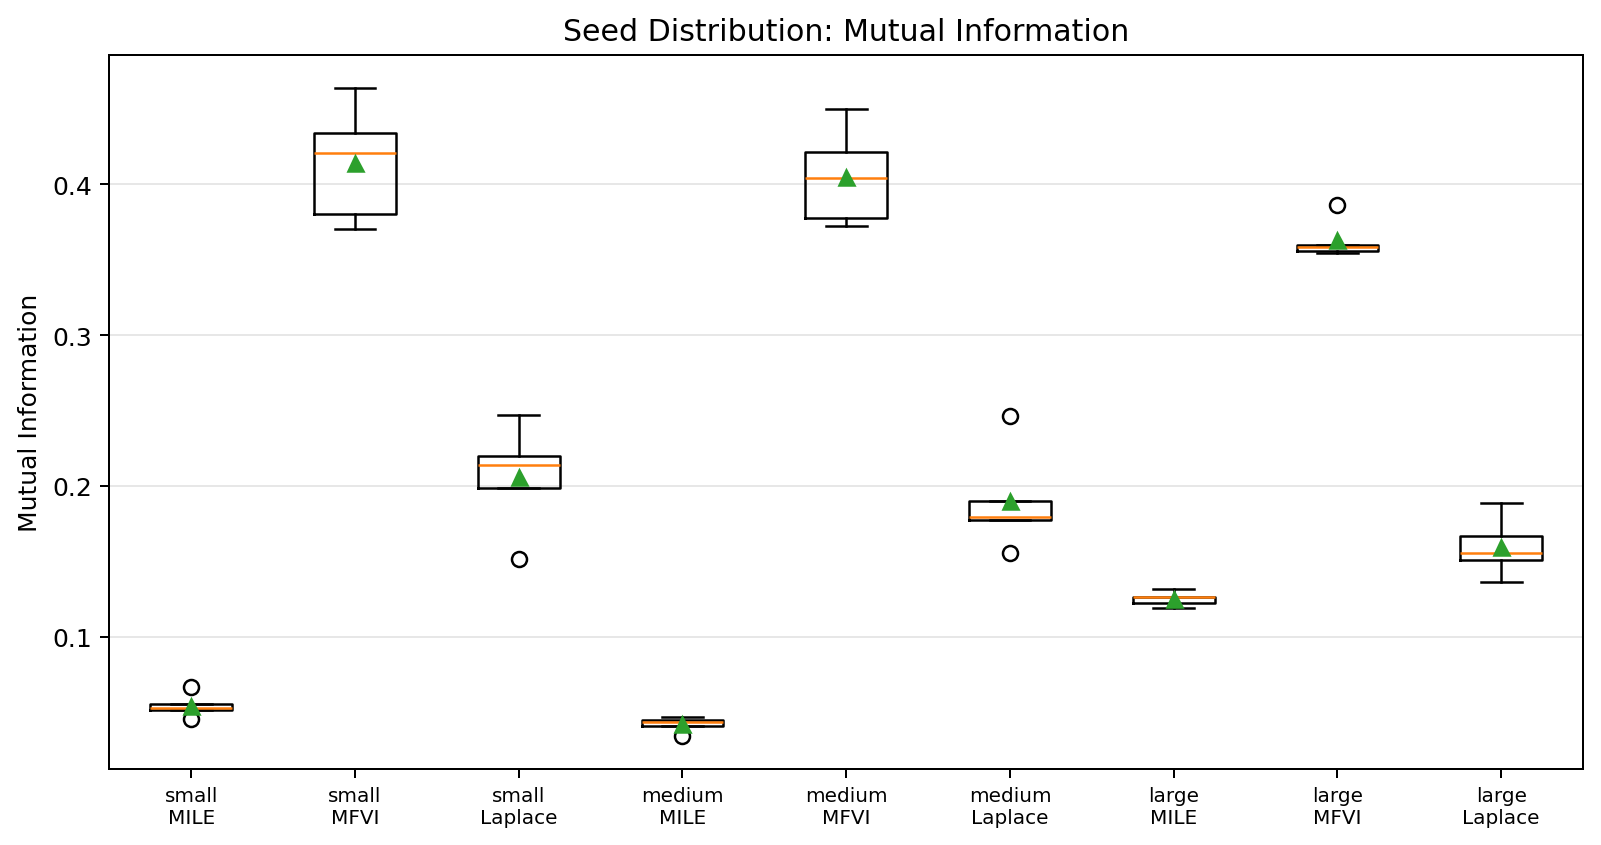
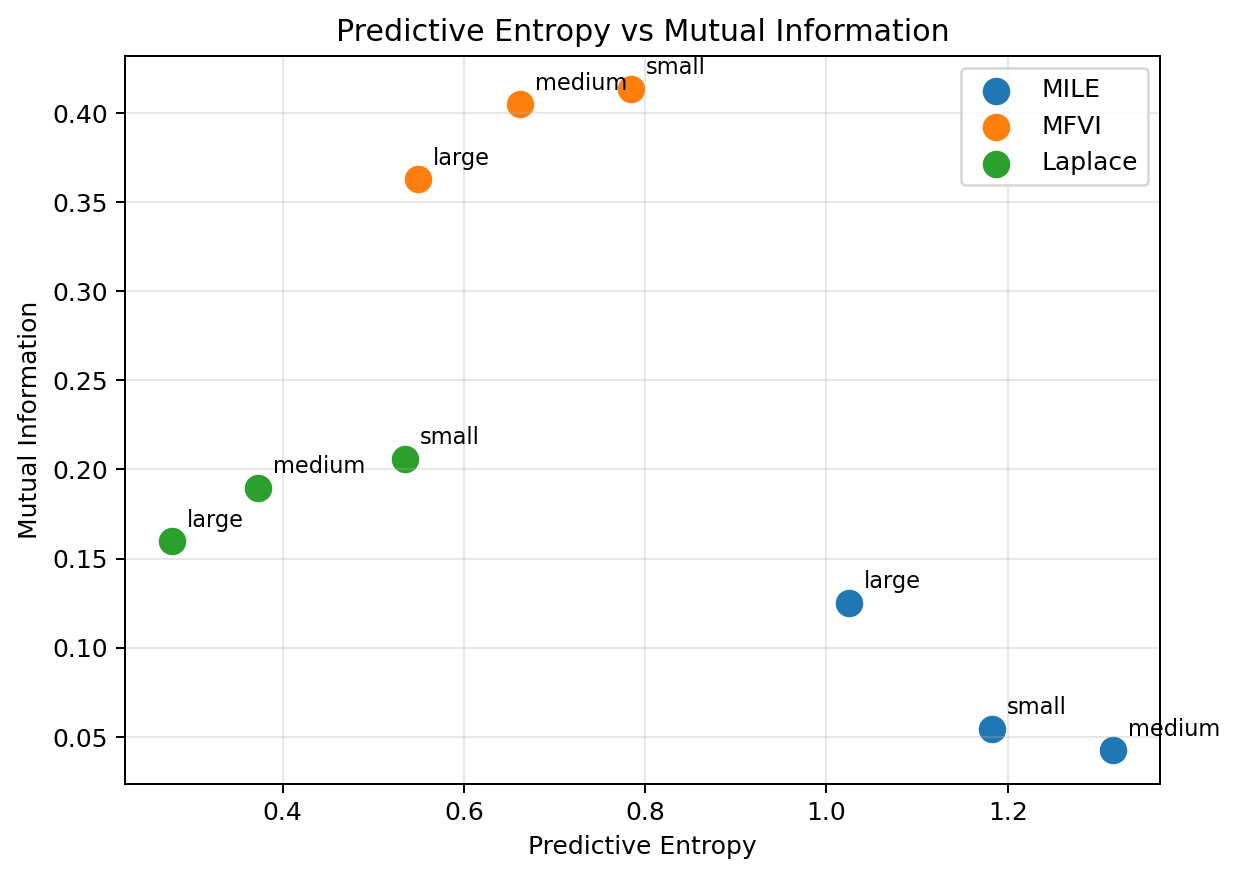
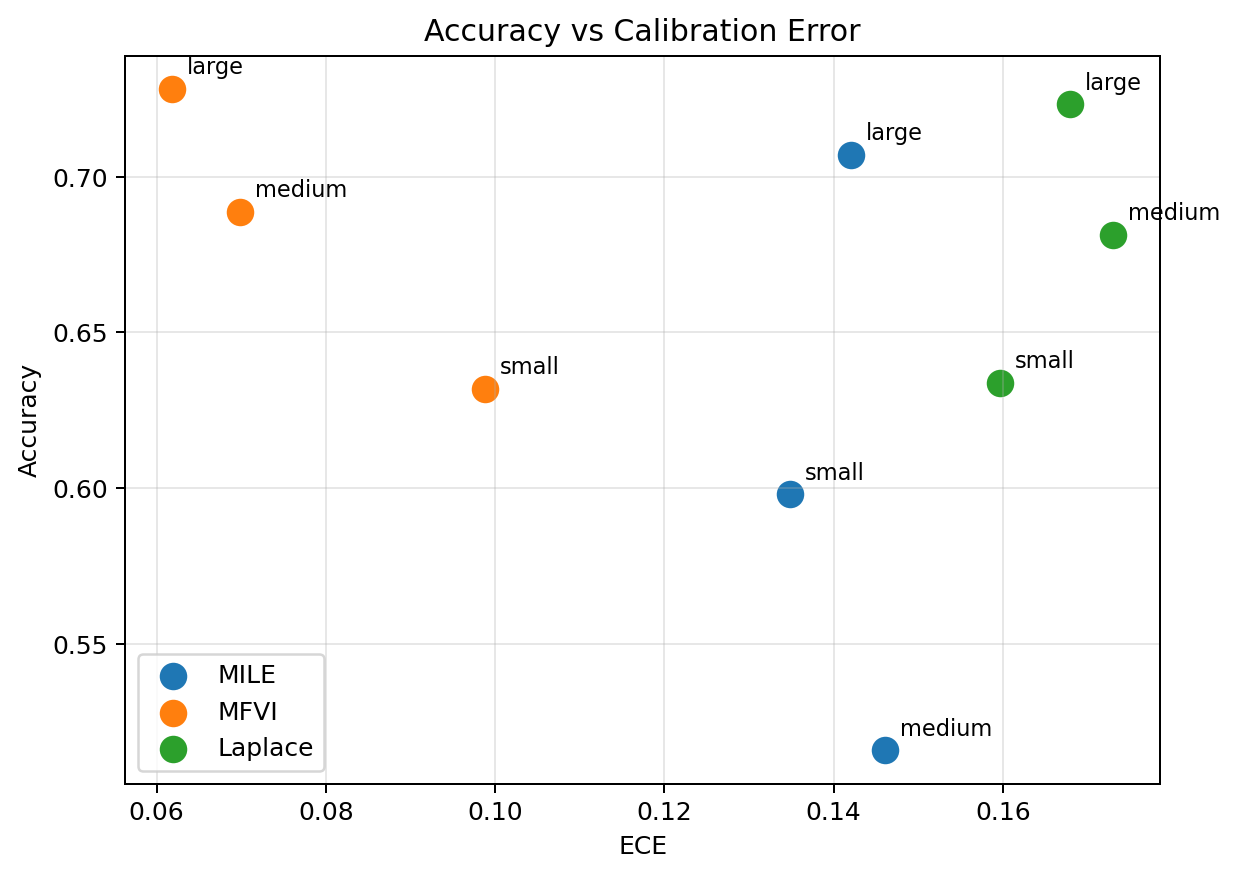
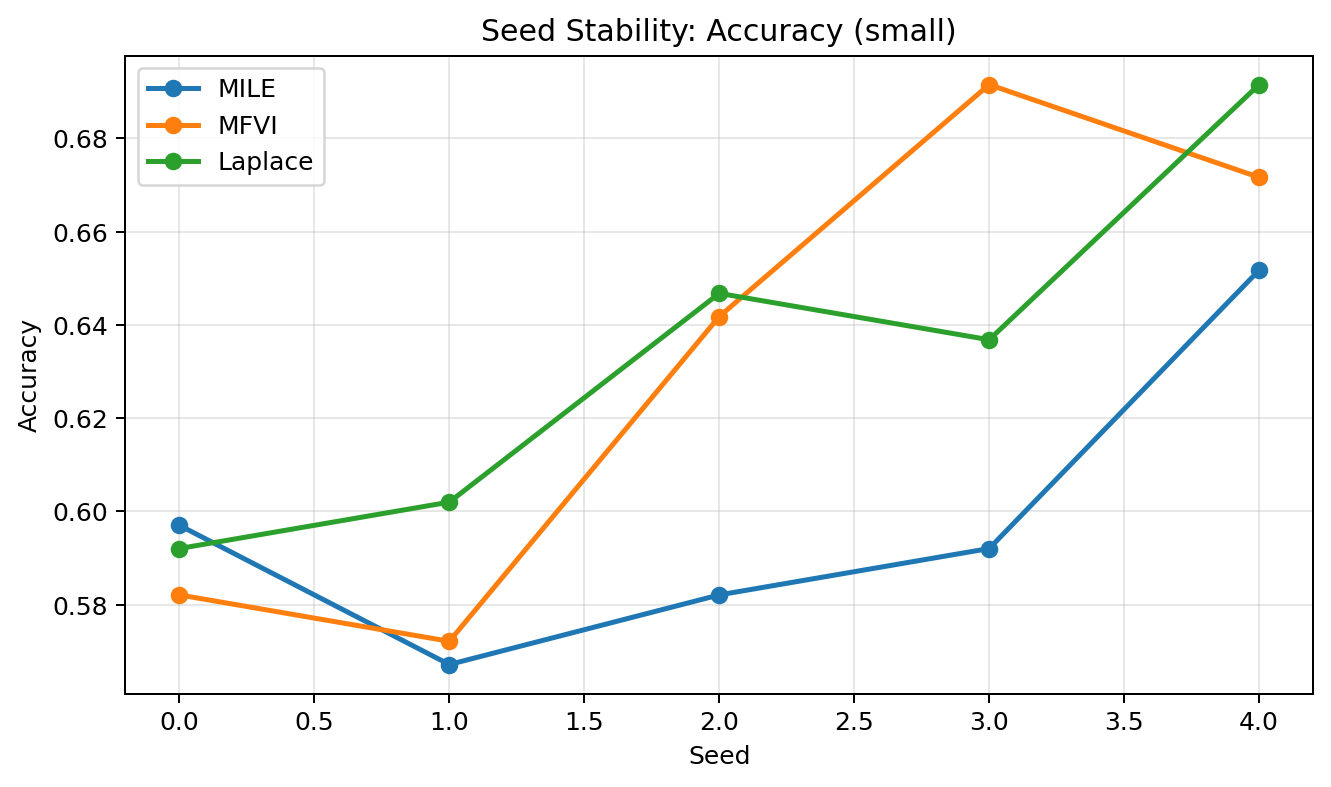
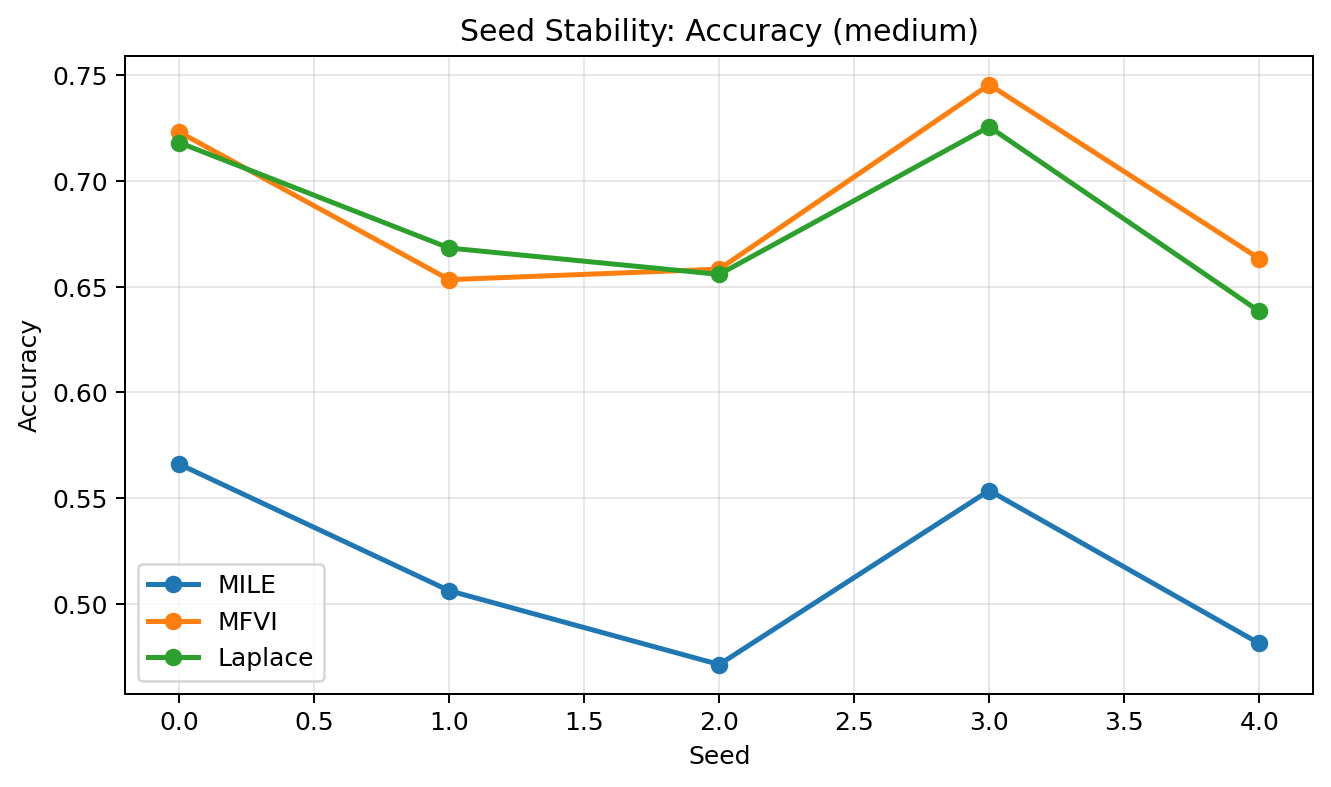
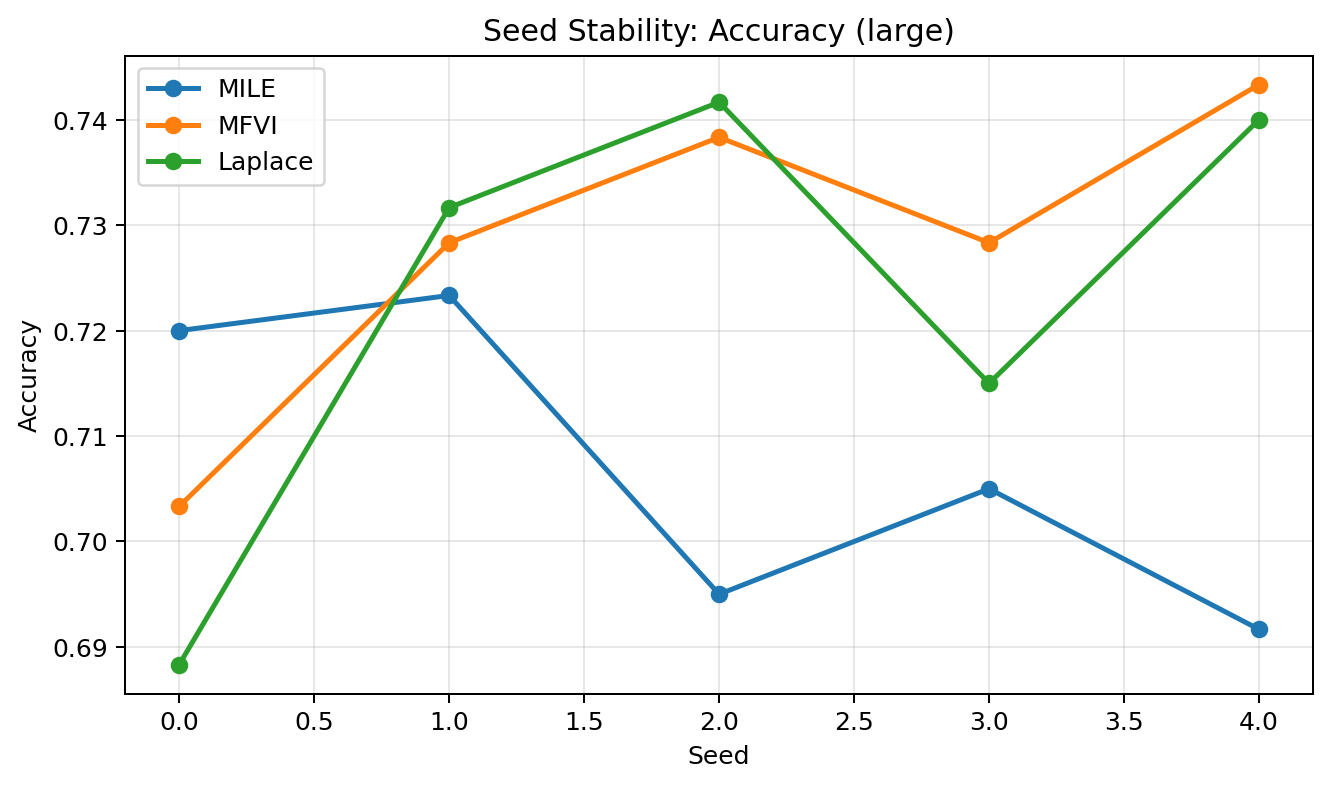

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import base64
from io import BytesIO
from IPython.display import HTML

# ==================================================
# READ DATA
# ==================================================

df = pd.read_excel(excel_path)
df.columns = df.columns.str.lower().str.strip()
df = df.loc[:, ~df.columns.str.contains("^unnamed")]

# ==================================================
# CLEAN NAMES
# ==================================================

df["size"] = df["size"].astype(str).str.lower().str.strip()

df["method_original"] = df["method"].astype(str)
df["method_clean"] = df["method_original"].str.lower().str.strip()

df["method"] = None
df.loc[df["method_clean"].str.contains("mile", na=False), "method"] = "MILE"
df.loc[df["method_clean"].str.contains("mfvi", na=False), "method"] = "MFVI"
df.loc[df["method_clean"].str.contains("laplace", na=False), "method"] = "Laplace"

metric_cols = [
    "acc",
    "ece",
    "brier",
    "lppd",
    "predictive_entropy",
    "mutual_information"
]

size_order = ["small", "medium", "large"]
method_order = ["MILE", "MFVI", "Laplace"]

df["size"] = pd.Categorical(df["size"], categories=size_order, ordered=True)
df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)

df = df.sort_values(["size", "method", "seed"])

print("Methods found:", df["method"].unique())
print("Sizes found:", df["size"].unique())

# ==================================================
# SUMMARY TABLE
# ==================================================

summary = (
    df.groupby(["size", "method"], observed=False)[metric_cols]
    .agg(["mean", "std"])
    .reset_index()
)

summary.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in summary.columns
]

summary = summary.rename(columns={
    "acc_mean": "ACC_mean",
    "acc_std": "ACC_sd",
    "ece_mean": "ECE_mean",
    "ece_std": "ECE_sd",
    "brier_mean": "Brier_mean",
    "brier_std": "Brier_sd",
    "lppd_mean": "LPPD_mean",
    "lppd_std": "LPPD_sd",
    "predictive_entropy_mean": "Entropy_mean",
    "predictive_entropy_std": "Entropy_sd",
    "mutual_information_mean": "MI_mean",
    "mutual_information_std": "MI_sd",
})

summary["size"] = pd.Categorical(summary["size"], categories=size_order, ordered=True)
summary["method"] = pd.Categorical(summary["method"], categories=method_order, ordered=True)
summary = summary.sort_values(["size", "method"])

# ==================================================
# PAPER TABLE
# ==================================================

paper = summary[["size", "method"]].copy()

for metric in ["ACC", "ECE", "Brier", "LPPD", "Entropy", "MI"]:
    paper[metric] = (
        summary[f"{metric}_mean"].map(lambda x: f"{x:.4f}")
        + " ± "
        + summary[f"{metric}_sd"].map(lambda x: f"{x:.4f}")
    )

# ==================================================
# HELPER
# ==================================================

def fig_to_base64():
    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=180, bbox_inches="tight")
    plt.close()
    return base64.b64encode(buf.getvalue()).decode("utf-8")

plots_html = ""

def add_html_plot(title):
    global plots_html
    img = fig_to_base64()
    plots_html += f"<h2>{title}</h2><img src='data:image/png;base64,{img}'>"

# ==================================================
# 1. LINE PLOTS WITH SD ERROR BARS
# ==================================================

def add_metric_plot(metric_mean, metric_sd, title, ylabel):
    plt.figure(figsize=(7.5, 4.5))

    for method in method_order:
        tmp = summary[summary["method"].astype(str) == method].copy()
        tmp = tmp.sort_values("size")

        plt.errorbar(
            tmp["size"].astype(str),
            tmp[metric_mean],
            yerr=tmp[metric_sd],
            marker="o",
            capsize=5,
            linewidth=2,
            label=method
        )

    plt.title(title)
    plt.xlabel("Model size")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    add_html_plot(title)

add_metric_plot("ACC_mean", "ACC_sd", "Accuracy vs Model Size", "Accuracy")
add_metric_plot("ECE_mean", "ECE_sd", "ECE vs Model Size", "ECE")
add_metric_plot("Brier_mean", "Brier_sd", "Brier Score vs Model Size", "Brier Score")
add_metric_plot("LPPD_mean", "LPPD_sd", "LPPD vs Model Size", "LPPD")
add_metric_plot("Entropy_mean", "Entropy_sd", "Predictive Entropy vs Model Size", "Predictive Entropy")
add_metric_plot("MI_mean", "MI_sd", "Mutual Information vs Model Size", "Mutual Information")

# ==================================================
# 2. BOXPLOTS BY SEED
# ==================================================

for metric, ylabel in [
    ("acc", "Accuracy"),
    ("ece", "ECE"),
    ("predictive_entropy", "Predictive Entropy"),
    ("mutual_information", "Mutual Information")
]:
    plt.figure(figsize=(9, 4.8))

    data = []
    labels = []

    for size in size_order:
        for method in method_order:
            vals = df[
                (df["size"].astype(str) == size) &
                (df["method"].astype(str) == method)
            ][metric].dropna().values

            data.append(vals)
            labels.append(f"{size}\n{method}")

    plt.boxplot(data, labels=labels, showmeans=True)
    plt.title(f"Seed Distribution: {ylabel}")
    plt.ylabel(ylabel)
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0, fontsize=8)
    plt.tight_layout()
    add_html_plot(f"Seed Distribution: {ylabel}")

# ==================================================
# 3. ENTROPY VS MI SCATTER
# ==================================================

plt.figure(figsize=(7, 5))

for method in method_order:
    tmp = summary[summary["method"].astype(str) == method].copy()

    plt.scatter(
        tmp["Entropy_mean"],
        tmp["MI_mean"],
        s=100,
        label=method
    )

    for _, row in tmp.iterrows():
        plt.annotate(
            str(row["size"]),
            (row["Entropy_mean"], row["MI_mean"]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9
        )

plt.xlabel("Predictive Entropy")
plt.ylabel("Mutual Information")
plt.title("Predictive Entropy vs Mutual Information")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
add_html_plot("Predictive Entropy vs Mutual Information")

# ==================================================
# 4. ACCURACY VS ECE TRADE-OFF
# ==================================================

plt.figure(figsize=(7, 5))

for method in method_order:
    tmp = summary[summary["method"].astype(str) == method].copy()

    plt.scatter(
        tmp["ECE_mean"],
        tmp["ACC_mean"],
        s=100,
        label=method
    )

    for _, row in tmp.iterrows():
        plt.annotate(
            str(row["size"]),
            (row["ECE_mean"], row["ACC_mean"]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9
        )

plt.xlabel("ECE")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Calibration Error")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
add_html_plot("Accuracy vs Calibration Error")


# ==================================================
# 7. SEED STABILITY LINE PLOTS
# ==================================================

for size in size_order:
    tmp_size = df[df["size"].astype(str) == size].copy()

    plt.figure(figsize=(7.5, 4.5))

    for method in method_order:
        tmp = tmp_size[tmp_size["method"].astype(str) == method].copy()
        tmp = tmp.sort_values("seed")

        plt.plot(
            tmp["seed"],
            tmp["acc"],
            marker="o",
            linewidth=2,
            label=method
        )

    plt.title(f"Seed Stability: Accuracy ({size})")
    plt.xlabel("Seed")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    add_html_plot(f"Seed Stability: Accuracy ({size})")

# ==================================================
# PER-METHOD TABLES
# ==================================================

method_tables_html = ""

for method in method_order:
    tmp = paper[paper["method"].astype(str) == method].copy()
    method_tables_html += f"<h2>{method}: Small / Medium / Large</h2>"
    method_tables_html += tmp.to_html(index=False)

# ==================================================
# SHORT AUTOMATIC FINDINGS
# ==================================================

best_acc = summary.loc[summary["ACC_mean"].idxmax()]
best_ece = summary.loc[summary["ECE_mean"].idxmin()]
best_brier = summary.loc[summary["Brier_mean"].idxmin()]
best_lppd = summary.loc[summary["LPPD_mean"].idxmax()]
highest_entropy = summary.loc[summary["Entropy_mean"].idxmax()]
highest_mi = summary.loc[summary["MI_mean"].idxmax()]

findings_html = f"""
<h2>Automatic Key Findings</h2>
<ul>
<li>Best Accuracy: <b>{best_acc['method']} {best_acc['size']}</b> with {best_acc['ACC_mean']:.4f} ± {best_acc['ACC_sd']:.4f}.</li>
<li>Best ECE: <b>{best_ece['method']} {best_ece['size']}</b> with {best_ece['ECE_mean']:.4f} ± {best_ece['ECE_sd']:.4f}.</li>
<li>Best Brier Score: <b>{best_brier['method']} {best_brier['size']}</b> with {best_brier['Brier_mean']:.4f} ± {best_brier['Brier_sd']:.4f}.</li>
<li>Best LPPD: <b>{best_lppd['method']} {best_lppd['size']}</b> with {best_lppd['LPPD_mean']:.4f} ± {best_lppd['LPPD_sd']:.4f}.</li>
<li>Highest Predictive Entropy: <b>{highest_entropy['method']} {highest_entropy['size']}</b> with {highest_entropy['Entropy_mean']:.4f} ± {highest_entropy['Entropy_sd']:.4f}.</li>
<li>Highest Mutual Information: <b>{highest_mi['method']} {highest_mi['size']}</b> with {highest_mi['MI_mean']:.4f} ± {highest_mi['MI_sd']:.4f}.</li>
</ul>
"""

# ==================================================
# HTML REPORT
# ==================================================

html = f"""
<html>
<head>
<meta charset="utf-8">
<title>Bayesian Uncertainty Results Report</title>

<style>
body {{
    font-family: Arial, sans-serif;
    margin: 40px;
    color: #222;
}}

table {{
    border-collapse: collapse;
    margin-bottom: 35px;
    font-size: 14px;
}}

th, td {{
    border: 1px solid #ccc;
    padding: 6px 10px;
    text-align: center;
}}

th {{
    background-color: #f2f2f2;
}}

img {{
    max-width: 950px;
    display: block;
    margin-bottom: 45px;
}}

h1 {{
    margin-top: 40px;
}}

h2 {{
    margin-top: 35px;
}}
</style>
</head>

<body>

<h1>Bayesian Uncertainty Results Report</h1>


<h2>Overall Mean ± SD</h2>
{paper.to_html(index=False)}

{method_tables_html}


<h1>Visualizations</h1>
{plots_html}

</body>
</html>
"""

Path("report.html").write_text(html, encoding="utf-8")

print("Fertig: report.html wurde im aktuellen Arbeitsordner gespeichert.")
HTML("report.html")